# 10.1 Different kinds of timeseries tasks

# 10.2 A temperature forcasting example

In [2]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2025-07-08 11:06:47--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 54.231.171.208, 52.216.56.184, 54.231.132.184, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|54.231.171.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  19.4MB/s    in 0.7s    

2025-07-08 11:06:48 (19.4 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [3]:
import os
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]

print((header))
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [4]:
import numpy as np

temperature = np.zeros((len(lines)))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(',')[1:]]
    # Now, since the first column represents the temperature
    temperature[i] = values[1]
    raw_data[i, :] = values[:]


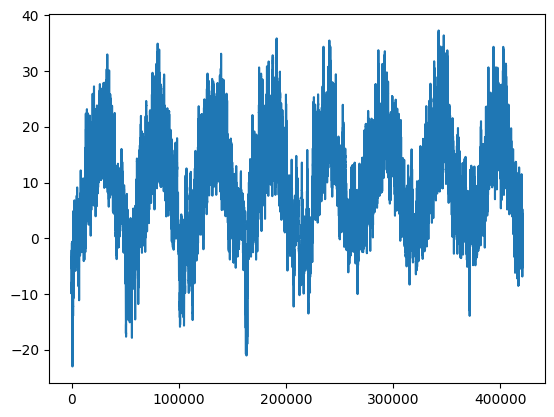

In [5]:
import matplotlib.pyplot as plt
plt.plot(range(len(temperature)), temperature)

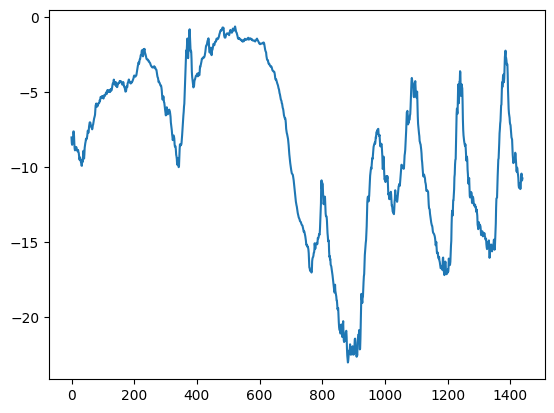

In [6]:
plt.plot(range(1440), temperature[: 1440])

In [7]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print(f"num_train_samples: {num_train_samples}")
print(f"num_val_samples: {num_val_samples}")
print(f"num_test_samples: {num_test_samples}")

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [8]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [9]:
# Example of using keras.timeseries_dataset_from_array()

from tensorflow import keras
int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2
)

In [10]:
for inputs, targets in dummy_dataset:
    print(inputs.shape)
    print(targets.shape)
    for i in range(inputs.shape[0]):
        print(inputs[i].numpy(), int(targets[i]))


(2, 3)
(2,)
[0 1 2] 3
[1 2 3] 4
(2, 3)
(2,)
[2 3 4] 5
[3 4 5] 6
(1, 3)
(1,)
[4 5 6] 7


In [11]:
sampling_rate = 6 # Observations that will be sampled at one data point per hour (Out of 6 per hour, we will only choose 1)
sequence_length = 120 # Observations will go back in 5 days
delay = sampling_rate * (sequence_length + 24 - 1) # target for a sequence will be the temperature 24 hours after the end of the sequence
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples
)

for samples, targets in train_dataset:
    print("samples shape: ", samples.shape)
    print("targets shape: ", targets.shape)
    break


samples shape:  (256, 120, 14)
targets shape:  (256,)


In [ ]:
# Let us first check with our naive method (baseline method)

def evaluate_naive_method(dataset):
    total_abs_err = 0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


In [ ]:
# Before Jumping to RNN, let's first try some very simple and cheap deep learning approach

from tensorflow import keras
from keras import layers
import tensorflow as tf

print(sequence_length, raw_data.shape[-1])
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
# Calculate the flattened dimension
flattened_dimension = sequence_length * raw_data.shape[-1]
# Use Reshape to explicitly flatten the input before the Dense layer
x = layers.Reshape((flattened_dimension,))(inputs)
# x = layers.Flatten()(inputs)
x = layers.Dense(units=16, activation='relu')(x)
outputs = layers.Dense(units=1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='jena_dense.keras',
        save_best_only=True
        )
]

model.compile(
    optimizer='rmsprop',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

120 14
Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - loss: 22.1611 - mae: 3.5752 - val_loss: 15.3317 - val_mae: 3.0873
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - loss: 10.4121 - mae: 2.5406 - val_loss: 10.7419 - val_mae: 2.5948
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - loss: 9.3632 - mae: 2.4095 - val_loss: 11.2969 - val_mae: 2.6660
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - loss: 8.7128 - mae: 2.3225 - val_loss: 11.9324 - val_mae: 2.7261
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 8.3088 - mae: 2.2664 - val_loss: 10.3998 - val_mae: 2.5587
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - loss: 7.9411 - mae: 2.2167 - val_loss: 11.0292 - val_mae: 2.6294
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - loss: 7.6480 - mae: 2.1749 - val_loss: 11.2103 - val_mae: 2.6492
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - loss: 7.4793 - mae: 2.1466 - val_loss: 13.1003 - val_mae: 2.8631
Epoch 9/10
819/819 ━━━━

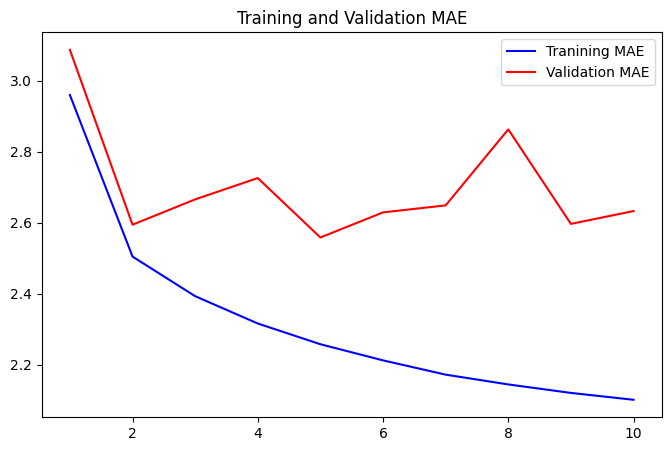

In [ ]:
import matplotlib.pyplot as plt
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'b', label="Tranining MAE")
plt.plot(epochs, val_loss, 'r', label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

In [ ]:
model = keras.models.load_model('jena_dense.keras')
print(f"Test MAE: {model.evaluate(test_dataset)}")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 11.4191 - mae: 2.6634
Test MAE: [11.464128494262695, 2.6682868003845215]
405/405 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 11.4218 - mae: 2.6637
Test MAE: 2.67


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        26,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,828 (210.27 KB)

 Trainable params: 26,913 (105.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,915 (105.14 KB)

In [ ]:
# Let's try 1D Convlutional layered model
# By 1D, it means that the filter wil slide only in one dimension

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(filters=8, kernel_size=24, activation='relu')(inputs) # Corrected Conv1D
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(filters=8, kernel_size=12, activation='relu')(x) # Corrected Conv1D
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(filters=8, kernel_size=6, activation='relu')(x) # Corrected Conv1D
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)

callbacks = [
    keras.callbacks.ModelCheckpoint( # Corrected ModelCheckpoint typo
        filepath='jena_conv.keras',
        save_best_only=True
    )
]

model.compile(
    optimizer='rmsprop',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 8.0403 - mae: 2.2259 - val_loss: 11.8281 - val_mae: 2.7217
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 7.6218 - mae: 2.1700 - val_loss: 10.5458 - val_mae: 2.5790
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - loss: 7.4489 - mae: 2.1473 - val_loss: 11.4758 - val_mae: 2.6728
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - loss: 7.2800 - mae: 2.1211 - val_loss: 12.8820 - val_mae: 2.8509
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - loss: 7.1090 - mae: 2.0949 - val_loss: 11.3231 - val_mae: 2.6670
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - loss: 7.0096 - mae: 2.0824 - val_loss: 12.2514 - val_mae: 2.7659
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - loss: 6.9293 - mae: 2.0699 - val_loss: 11.9616 - val_mae: 2.7379
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 6.8038 - mae: 2.0532 - val_loss: 11.3191 - val_mae: 2.6580
Epoch 9/10
819/819 ━━━━━━━━━━━━━

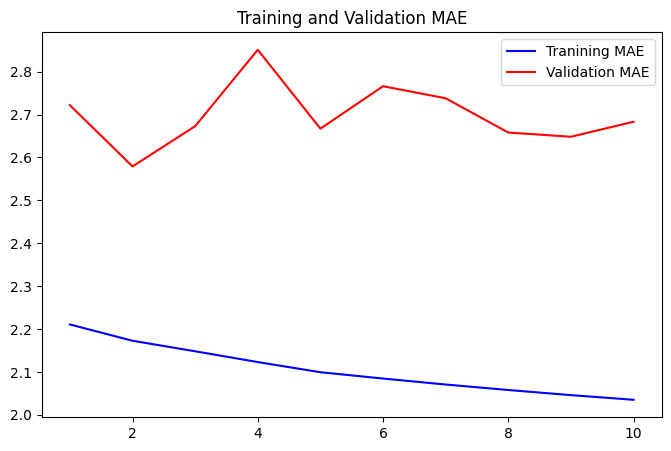

In [ ]:
import matplotlib.pyplot as plt
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'b', label="Tranining MAE")
plt.plot(epochs, val_loss, 'r', label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        26,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,828 (210.27 KB)

 Trainable params: 26,913 (105.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,915 (105.14 KB)

In [ ]:
model = keras.models.load_model('jena_conv.keras')
print(f"Test MAE: {model.evaluate(test_dataset)}")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 11.7677 - mae: 2.6999
Test MAE: [11.798830032348633, 2.7029294967651367]
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 11.7680 - mae: 2.6999
Test MAE: 2.70


In [ ]:
# A first recurrent baseline

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs = outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='jena_lstm.keras',
        save_best_only=True
    )
]

model.compile(
    optimizer='rmsprop',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - loss: 74.3060 - mae: 6.6432 - val_loss: 13.1461 - val_mae: 2.7425
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 73s 89ms/step - loss: 12.1050 - mae: 2.6918 - val_loss: 10.0241 - val_mae: 2.4590
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 72s 88ms/step - loss: 10.0552 - mae: 2.4789 - val_loss: 9.7593 - val_mae: 2.4541
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 76s 92ms/step - loss: 9.5053 - mae: 2.4051 - val_loss: 9.5052 - val_mae: 2.4200
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step - loss: 9.1462 - mae: 2.3592 - val_loss: 10.0905 - val_mae: 2.4253
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 80s 98ms/step - loss: 8.8731 - mae: 2.3193 - val_loss: 9.8444 - val_mae: 2.4185
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 97ms/step - loss: 8.6651 - mae: 2.2893 - val_loss: 10.3447 - val_mae: 2.4466
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 77s 94ms/step - loss: 8.5143 - mae: 2.2653 - val_loss: 10.0632 - val_mae: 2.4507
Epoch 9/10
819/819 ━━━━━━━━━━━━━

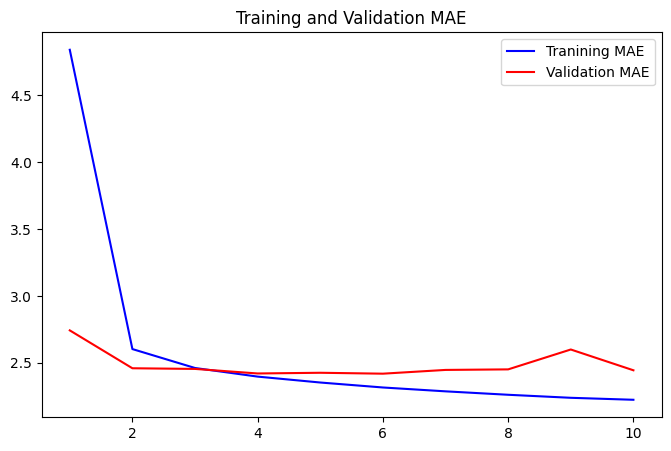

In [ ]:
import matplotlib.pyplot as plt
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'b', label="Tranining MAE")
plt.plot(epochs, val_loss, 'r', label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

In [ ]:
model = keras.models.load_model('jena_lstm.keras')
print(f"Test MAE: {model.evaluate(test_dataset)}")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 10.6185 - mae: 2.5489
Test MAE: [10.611054420471191, 2.5468249320983887]
405/405 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - loss: 10.5686 - mae: 2.5427
Test MAE: 2.55


# 10.3 Understanding Recurrent Neural Networks

Pseudocode Implementation of a toy RNN:
(f is learned during the training process)

    state_t = 0 # the state at t
    for input_t in input_sequence:
        output_t = f(input_t, state_t)
        state_t = output_t # the previous output becomes the state for the next iteration

More detailed pseudocode for an RNN (eliminating the function f):

    state_t = 0
    for input_t in input_sequence:
        output_t = activation(dot(W, input_t) + dot(U, state_t) + b)
        stata_t = output_t

In [ ]:
# Numpy implementation of a simple RNN
import numpy as np
timesteps = 100 # number of timesteps in an input sequence
input_features = 32 # dimensionality of the input feature space
output_features = 64 # dimensionality of the output feature space
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features, ))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features, ))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t

final_output_sequence = np.stack(successive_outputs, axis=0)

In [ ]:
# An RNN layer that return only last output step
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 16)
(None, 120, 16)


Pseudocode details of the LSTM architecture:

    output_t = activation(dot(state_t, U0) + dot(input_t, W0) + dot(ct_t, V0) +b)
    i_t = activation(dot(state_t, Ui) + dot(input_t, Wi) + b_i)
    f_t = activation(dot(state_t, Uf) + dot(input_t, Wf) + b_f)
    k_t = activation(dot(state_t, Uk) + dot(input_t, Wk) + b_k)

All the three transformations have their own weights and biases.

    c_t+1 = i_t * k_t + c_t * f_t

c stands for carry

# 10.4 Advanced use of recurrent neural networks

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25) (inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='jena_lstm_dropout.keras',
        save_best_only=True
    )
]

model.compile(
    optimizer='rmsprop',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 158s 188ms/step - loss: 47.7278 - mae: 5.1330 - val_loss: 9.8228 - val_mae: 2.4403
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 156s 190ms/step - loss: 15.4378 - mae: 3.0529 - val_loss: 9.4160 - val_mae: 2.3890
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 155s 189ms/step - loss: 14.5551 - mae: 2.9625 - val_loss: 9.0798 - val_mae: 2.3498
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 200s 186ms/step - loss: 14.1229 - mae: 2.9121 - val_loss: 9.1702 - val_mae: 2.3546
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 167s 204ms/step - loss: 13.7670 - mae: 2.8717 - val_loss: 9.1775 - val_mae: 2.3584
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 201s 203ms/step - loss: 13.4892 - mae: 2.8439 - val_loss: 9.1006 - val_mae: 2.3507
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 187s 184ms/step - loss: 13.2533 - mae: 2.8157 - val_loss: 9.0390 - val_mae: 2.3366
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 204s 187ms/step - loss: 12.9101 - mae: 2.7845 - val_loss: 8.8908 - val_mae: 2.3111
Epoch 9/50
819/8

In [ ]:
import matplotlib.pyplot as plt
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'b', label="Tranining MAE")
plt.plot(epochs, val_loss, 'r', label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

In [ ]:
model = keras.models.load_model('jena_lstm_dropout.keras')
print(f"Test MAE: {model.evaluate(test_dataset)}")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Recurrent models with very few parameters, like the ones in this chapter, tend to
 be significantly faster on a multicore CPU than on GPU, because they only involve
 small matrix multiplications, and the chain of multiplications is not well paralleliz
able due to the presence of a for loop. But larger RNNs can greatly benefit from a
 GPU runtime.

  As a way to speed up your RNN layer when you can’t use cuDNN, you can try unrolling
 it. Unrolling a for loop consists of removing the loop and simply inlining its content
 N times. In the case of the for loop of an RNN, unrolling can help TensorFlow opti
mize the underlying computation graph. However, it will also considerably increase
 the memory consumption of your RNN—as such, it’s only viable for relatively small
 sequences (around 100 steps or fewer). Also, note that you can only do this if the
 number of timesteps in the data is known in advance by the model (that is to say, if
 you pass a shape without any None entries to your initial Input()). It works like this:
 sequence_length cannot be None.

    inputs = keras.Input(shape=(sequence_length, num_features))
    x = layers.LSTM(32, recurrent_dropout=0.2, unroll=True)(inputs)
 Pass unroll=True to enable unrolling.

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)
callbacks = [
    keras.callbacks.Modelcheckpoint(
        filepath='jena_stacked_grub_dropout.keras',
        save_best_only=True
    )
]
model.compile(
    optimizer='rmsprop',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks
)

In [ ]:
model = keras.models.load_model('jena_lstm_dropout.keras')
print(f"Test MAE: {model.evaluate(test_dataset)}")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

In [ ]:
import matplotlib.pyplot as plt
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'b', label="Tranining MAE")
plt.plot(epochs, val_loss, 'r', label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

Reversed RNN works even worse than baseline.

We could use bidirectional RNN (syntax given below). But they work for text better, not for this task. Before the discovery of Transformer architecture, they we considered as state-of-the-art.

But this task is not for them.

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)